# Notebook 05 — Polynomial Fitting

We have lane pixel clouds from sliding window. Now we fit a smooth 2nd-degree
polynomial through each cloud — that polynomial **is** our lane prediction.

Key choice: we fit x as a function of y (`x = ay² + by + c`) because lanes are
predominantly vertical in the BEV. Fitting y = f(x) would fail on vertical
sections (infinite slope).

NumPy's `np.polyfit(y, x, 2)` returns coefficients `[a, b, c]` that minimize
squared error. The resulting curve passes through the noisy pixel cloud
in the least-squares-optimal way.

After fitting, we evaluate the polynomial at every y-row in the BEV, giving
us a sequence of x-positions that smoothly trace the lane.

Left lane coefficients (a, b, c): [ 1.33663693e-05 -3.62409018e-03  6.79690369e+01]
Right lane coefficients (a, b, c): [-1.22472989e-05  8.11730836e-02  6.58129884e+02]


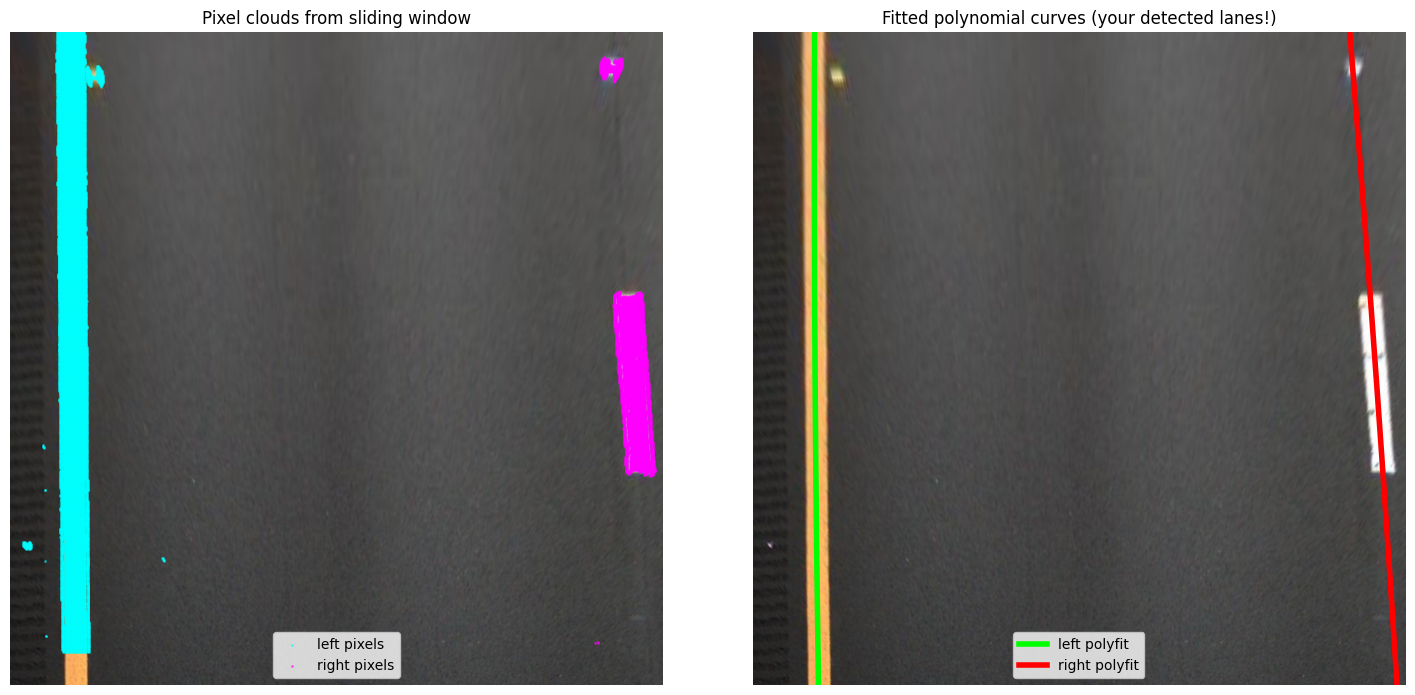

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt

from tusimple_loader import TuSimpleDataset
from perspective import PerspectiveWarper
from thresholding import threshold_pipeline
from sliding_window import sliding_window_search

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 100

dataset = TuSimpleDataset(
    annotation_file=project_root / "data/tusimple/test_subset/test_label_subset.json",
    image_root=project_root / "data/tusimple/test_subset",
)
warper = PerspectiveWarper()


def fit_lane_polynomial(x_pixels, y_pixels, degree=2):
    """Fit a polynomial x = f(y) through the lane pixel cloud.

    Args:
        x_pixels: 1D array of x-coordinates of lane pixels
        y_pixels: 1D array of y-coordinates of lane pixels
        degree:   polynomial degree (2 is standard for lane detection)

    Returns:
        coeffs: numpy array of polynomial coefficients [a, b, c] for degree 2
                meaning x = a*y^2 + b*y + c
                Returns None if there are too few pixels to fit.
    """
    if len(x_pixels) < degree + 1:
        return None
    return np.polyfit(y_pixels, x_pixels, degree)


def evaluate_polynomial(coeffs, y_values):
    """Compute x positions for each y given polynomial coefficients."""
    return np.polyval(coeffs, y_values)


# === Run the full pipeline on a sample ===
sample = dataset[0]
img_rgb = cv2.cvtColor(cv2.imread(str(sample.image_path)), cv2.COLOR_BGR2RGB)
bev = warper.warp_image(img_rgb)
mask = threshold_pipeline(bev)
sw = sliding_window_search(mask)

# Fit polynomials
left_coeffs = fit_lane_polynomial(sw["left_x_idx"], sw["left_y_idx"]) if sw["left_detected"] else None
right_coeffs = fit_lane_polynomial(sw["right_x_idx"], sw["right_y_idx"]) if sw["right_detected"] else None

print(f"Left lane coefficients (a, b, c): {left_coeffs}")
print(f"Right lane coefficients (a, b, c): {right_coeffs}")

# Evaluate the polynomial at every row of the BEV
H = bev.shape[0]
y_eval = np.linspace(0, H - 1, H)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: BEV with pixel clouds
axes[0].imshow(bev)
if sw["left_detected"]:
    axes[0].scatter(sw["left_x_idx"], sw["left_y_idx"], c="cyan", s=1, alpha=0.5, label="left pixels")
if sw["right_detected"]:
    axes[0].scatter(sw["right_x_idx"], sw["right_y_idx"], c="magenta", s=1, alpha=0.5, label="right pixels")
axes[0].set_title("Pixel clouds from sliding window")
axes[0].legend()
axes[0].axis("off")

# Right: BEV with fitted curves
axes[1].imshow(bev)
if left_coeffs is not None:
    left_x = evaluate_polynomial(left_coeffs, y_eval)
    axes[1].plot(left_x, y_eval, color="lime", linewidth=4, label="left polyfit")
if right_coeffs is not None:
    right_x = evaluate_polynomial(right_coeffs, y_eval)
    axes[1].plot(right_x, y_eval, color="red", linewidth=4, label="right polyfit")
axes[1].set_title("Fitted polynomial curves (your detected lanes!)")
axes[1].legend()
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 2. Project the polynomial back onto the camera image

The polynomial lives in BEV coordinates. To draw it on the original camera image,
we sample many points along it, transform them through `M_inv`, and connect them
with thick colored lines. This is **the actual visible output of our lane detector.**

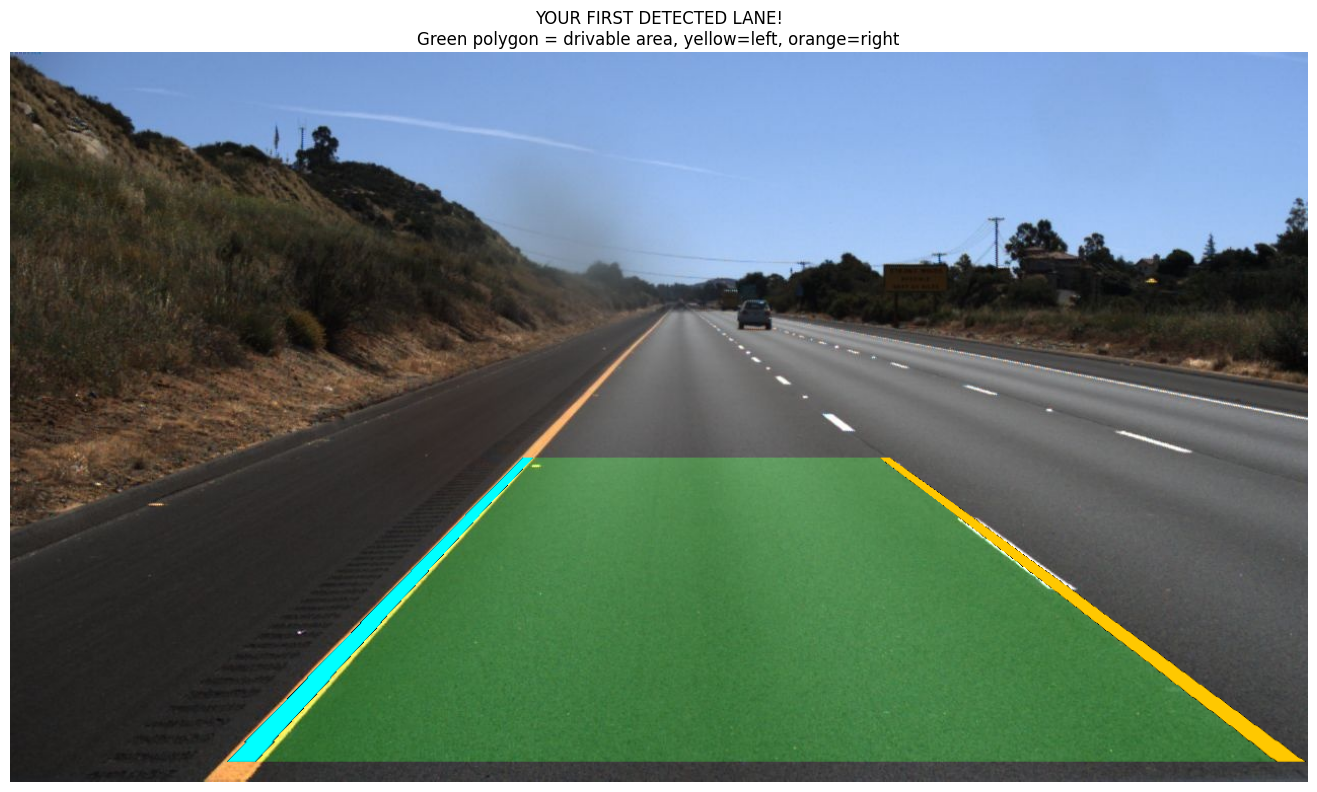

In [3]:
def draw_lane_overlay(image_camera, bev_shape, warper,
                      left_coeffs, right_coeffs):
    """Draw the detected lanes on the original camera image.

    Returns a copy of image_camera with lanes overlaid.
    """
    H = bev_shape[0]
    y_eval = np.linspace(0, H - 1, H)
    
    # Build a transparent overlay layer in BEV space
    overlay = np.zeros_like(image_camera)
    
    if left_coeffs is not None and right_coeffs is not None:
        left_x = evaluate_polynomial(left_coeffs, y_eval)
        right_x = evaluate_polynomial(right_coeffs, y_eval)
        
        # Build a polygon for the entire lane area
        left_pts = np.array([np.transpose(np.vstack([left_x, y_eval]))])
        right_pts = np.array([np.flipud(np.transpose(np.vstack([right_x, y_eval])))])
        polygon_pts = np.hstack((left_pts, right_pts)).astype(np.int32)
        
        # Draw filled polygon on a BEV canvas
        bev_overlay = np.zeros((bev_shape[0], bev_shape[1], 3), dtype=np.uint8)
        cv2.fillPoly(bev_overlay, polygon_pts, (0, 200, 0))
        
        # Warp this overlay back to camera view
        overlay = warper.unwarp_image(
            bev_overlay,
            output_size=(image_camera.shape[1], image_camera.shape[0]),
        )
    
    # Also draw the polynomial curves themselves (thicker, on top)
    bev_lines = np.zeros((bev_shape[0], bev_shape[1], 3), dtype=np.uint8)
    if left_coeffs is not None:
        left_x = evaluate_polynomial(left_coeffs, y_eval)
        pts = np.array(list(zip(left_x.astype(int), y_eval.astype(int))), dtype=np.int32)
        cv2.polylines(bev_lines, [pts], False, (0, 255, 255), thickness=15)
    if right_coeffs is not None:
        right_x = evaluate_polynomial(right_coeffs, y_eval)
        pts = np.array(list(zip(right_x.astype(int), y_eval.astype(int))), dtype=np.int32)
        cv2.polylines(bev_lines, [pts], False, (255, 200, 0), thickness=15)
    
    lines_camera = warper.unwarp_image(
        bev_lines,
        output_size=(image_camera.shape[1], image_camera.shape[0]),
    )
    
    # Blend: image + 30% green polygon + lines on top
    result = cv2.addWeighted(image_camera, 1.0, overlay, 0.3, 0)
    line_mask = lines_camera.sum(axis=2) > 0
    result[line_mask] = lines_camera[line_mask]
    
    return result


# Test it
output = draw_lane_overlay(img_rgb, bev.shape[:2], warper,
                            left_coeffs, right_coeffs)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(output)
ax.set_title("YOUR FIRST DETECTED LANE!\nGreen polygon = drivable area, yellow=left, orange=right")
ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Run the full pipeline on multiple samples

The real test: how does this perform on the 6 diagnostic samples we've been
using throughout the project? We expect:
- Sample 0, 95: clean detection ✅
- Sample 15: only right lane drawn (left was correctly rejected)
- Sample 30: probably wonky (concrete-noise polluted both lanes)
- Sample 50: only left lane drawn (right was correctly rejected)
- Sample 75: marginal — both detected but pixel counts low

Saved single-frame pipeline results figure for the report.


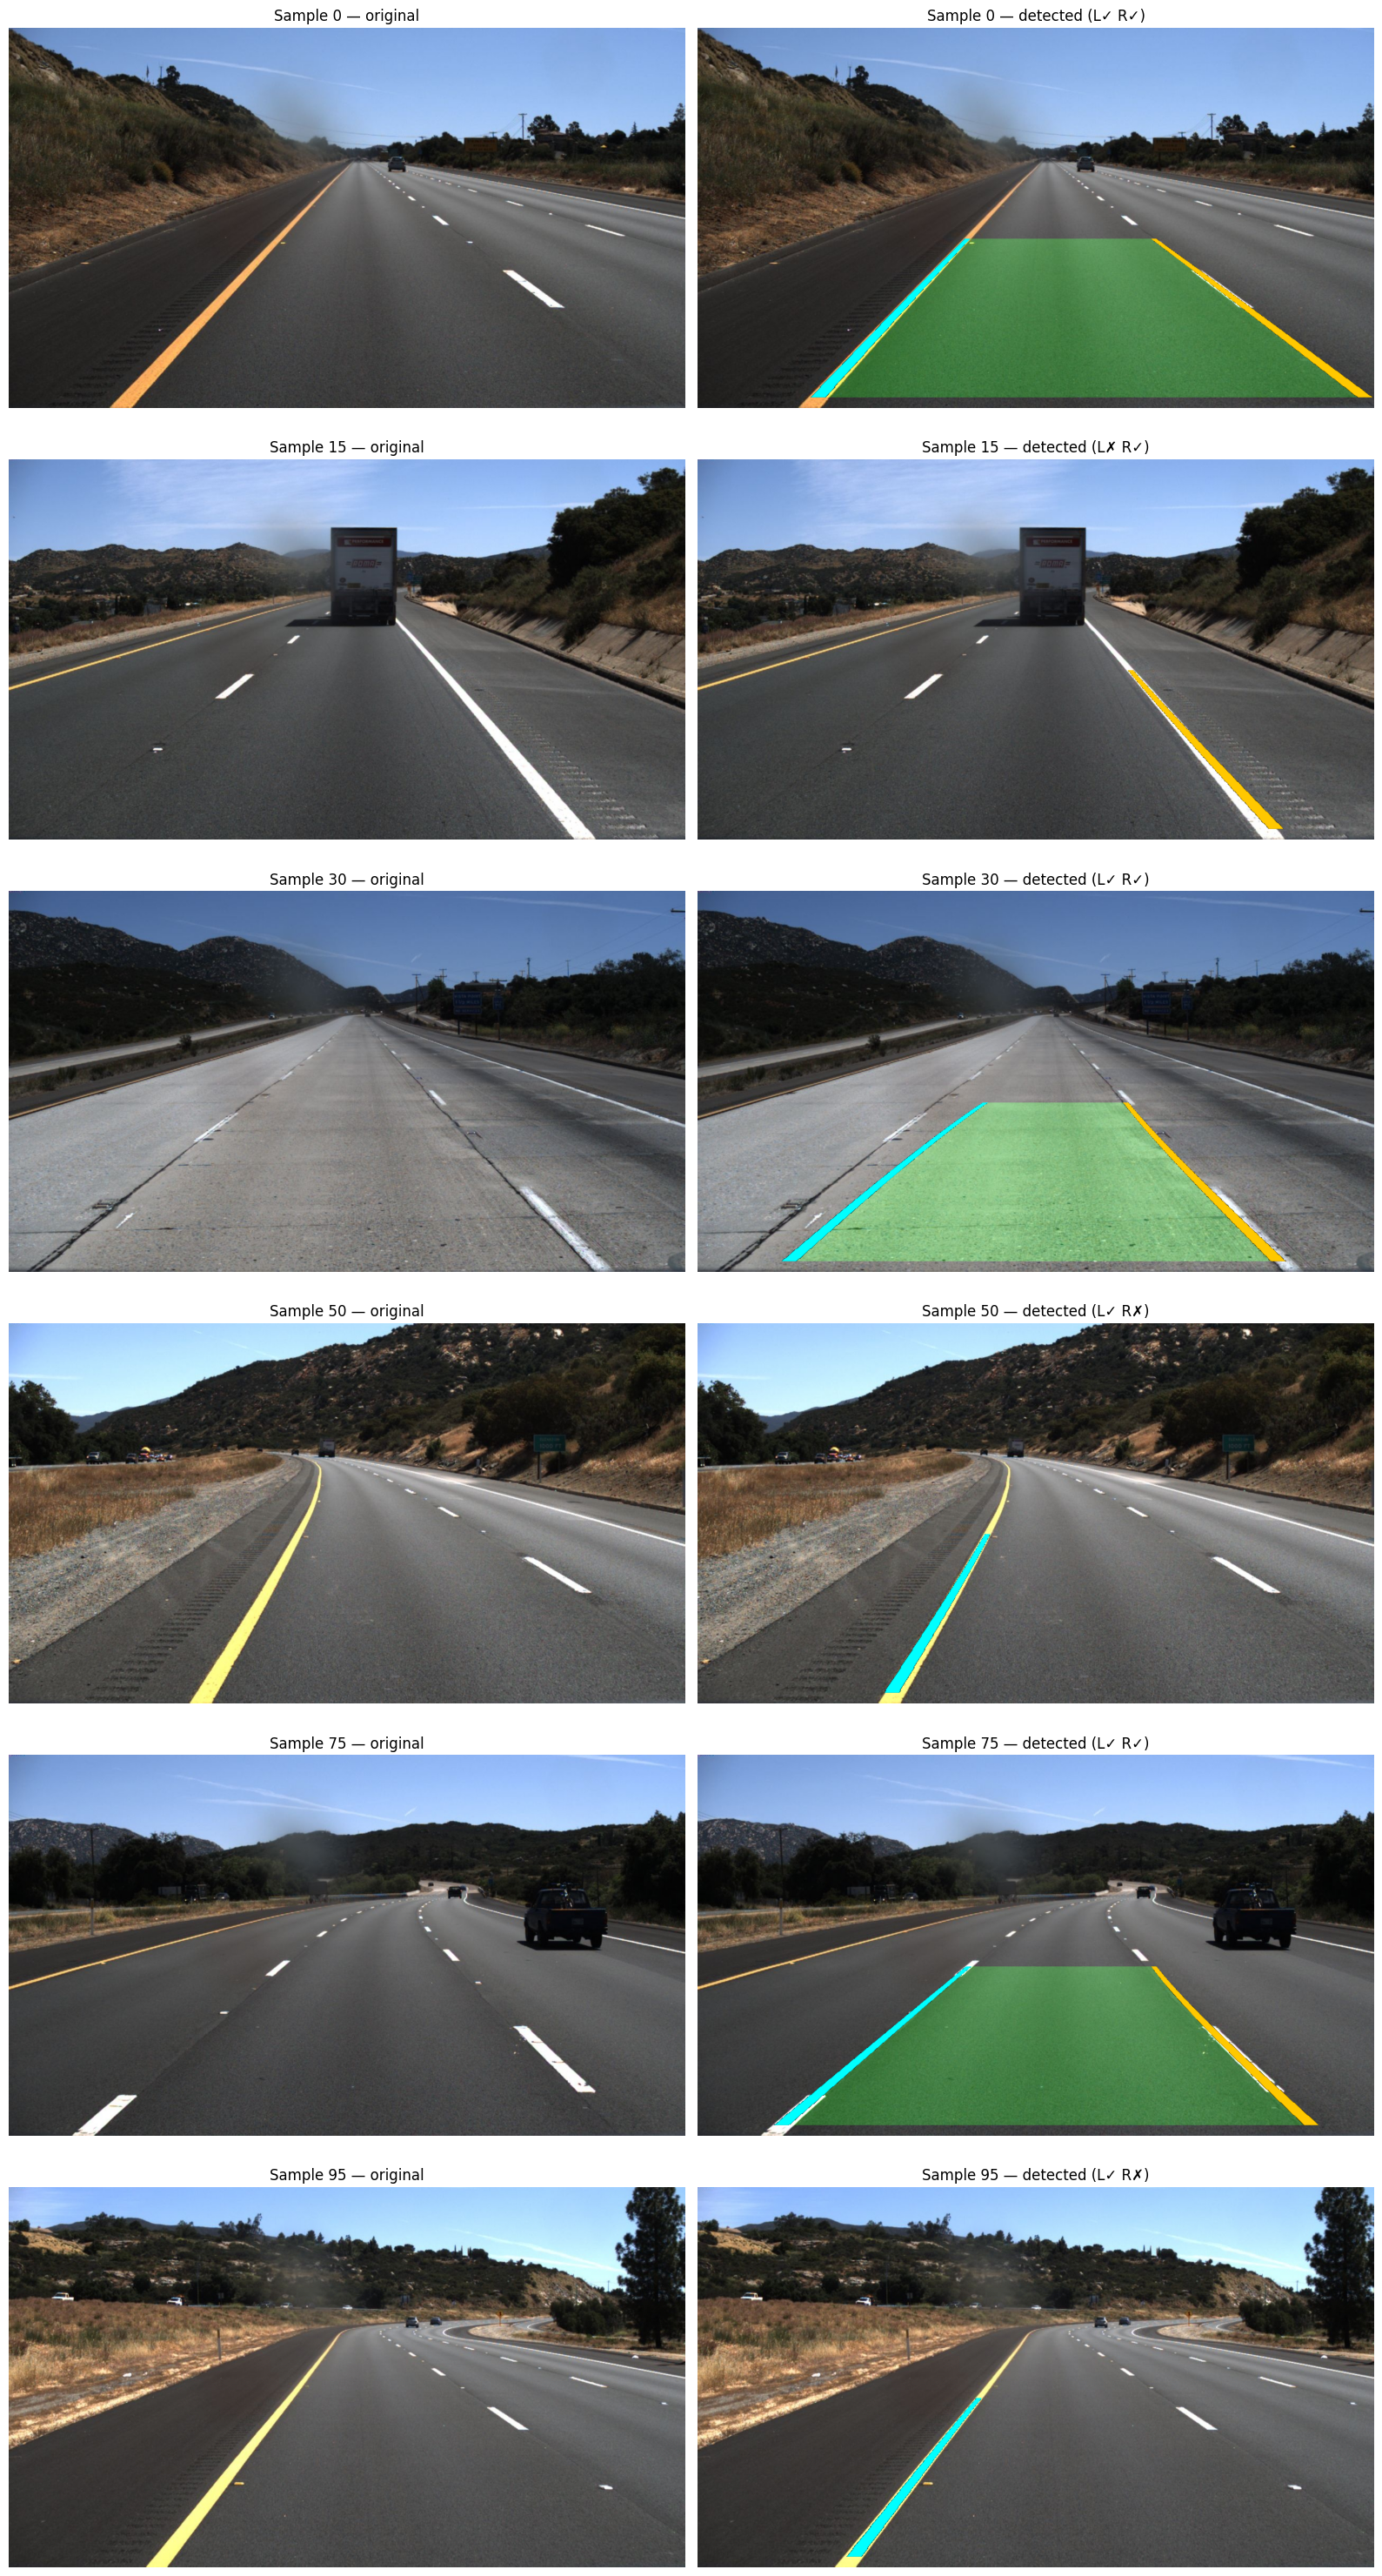

In [5]:
def full_pipeline(image_rgb: np.ndarray, warper: PerspectiveWarper):
    """Run the entire classical CV pipeline on a single camera-view image.

    Returns a dict with all intermediate outputs (useful for debugging).
    """
    bev = warper.warp_image(image_rgb)
    mask = threshold_pipeline(bev)
    sw = sliding_window_search(mask)
    
    left_coeffs = None
    right_coeffs = None
    if sw["left_detected"]:
        left_coeffs = fit_lane_polynomial(sw["left_x_idx"], sw["left_y_idx"])
    if sw["right_detected"]:
        right_coeffs = fit_lane_polynomial(sw["right_x_idx"], sw["right_y_idx"])
    
    overlay_camera = draw_lane_overlay(image_rgb, bev.shape[:2], warper,
                                        left_coeffs, right_coeffs)
    
    return {
        "bev": bev,
        "mask": mask,
        "sliding_window_result": sw,
        "left_coeffs": left_coeffs,
        "right_coeffs": right_coeffs,
        "overlay": overlay_camera,
    }


# Run on 6 samples
sample_indices = [0, 15, 30, 50, 75, 95]
fig, axes = plt.subplots(len(sample_indices), 2, figsize=(16, 5 * len(sample_indices)))

for row, idx in enumerate(sample_indices):
    s = dataset[idx]
    img_rgb_i = cv2.cvtColor(cv2.imread(str(s.image_path)), cv2.COLOR_BGR2RGB)
    result = full_pipeline(img_rgb_i, warper)
    
    sw = result["sliding_window_result"]
    L = "✓" if sw["left_detected"] else "✗"
    R = "✓" if sw["right_detected"] else "✗"
    
    axes[row, 0].imshow(img_rgb_i)
    axes[row, 0].set_title(f"Sample {idx} — original")
    axes[row, 0].axis("off")
    
    axes[row, 1].imshow(result["overlay"])
    axes[row, 1].set_title(f"Sample {idx} — detected (L{L} R{R})")
    axes[row, 1].axis("off")

plt.tight_layout()

fig.savefig(project_root / "results" / "single_frame_pipeline_results.png", dpi=120, bbox_inches="tight")
print("Saved single-frame pipeline results figure for the report.")

plt.show()